# Análise de Dados de Aluguel de Bicicletas

**Contexto**: Você trabalha para uma empresa de aluguel de bicicletas que opera em uma cidade. Eles forneceram um conjunto de dados com informações sobre aluguéis diários. Sua tarefa é usar o Pandas para responder perguntas específicas e identificar padrões nos dados.

**Dataset**: Crie um DataFrame com os seguintes dados (você pode copiar e colar no seu código):

```python
import pandas as pd

dados = {
    'Dia': ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08'],
    'Estação': ['Verão', 'Verão', 'Verão', 'Verão', 'Verão', 'Verão', 'Verão', 'Verão'],
    'Temperatura': [25.0, 22.5, 20.0, 18.5, 19.0, 23.0, 26.5, 24.0],
    'Chuva': [0, 0, 5, 10, 2, 0, 0, 3],
    'Aluguéis': [200, 180, 120, 80, 150, 220, 250, 170],
    'Feriado': [True, False, False, False, False, False, True, False]
}

df = pd.DataFrame(dados)
```

**Tarefas**:

1. **Exploração Inicial**:
   - Exiba as primeiras 3 linhas do DataFrame.
   - Verifique se há valores ausentes.
   - Mostre um resumo estatístico das colunas numéricas (`Temperatura`, `Chuva`, `Aluguéis`).

2. **Manipulação de Dados**:
   - Crie uma nova coluna chamada `Aluguéis_por_Celsius` que calcule o número de aluguéis por grau de temperatura (`Aluguéis` / `Temperatura`).
   - Calcule o total de aluguéis realizados em dias com chuva (onde `Chuva` > 0).

3. **Análise por Agrupamento**:
   - Agrupe os dados por `Feriado` e calcule a média de `Aluguéis` para dias feriados e não feriados.
   - Agrupe os dados por `Chuva` (considere criar uma categoria: "Sem Chuva" para `Chuva == 0` e "Com Chuva" para `Chuva > 0`) e calcule o total de aluguéis em cada categoria.

4. **Filtros**:
   - Filtre os dias em que a temperatura foi maior que 20°C e o número de aluguéis foi superior a 150.
   - Filtre os dias com chuva (onde `Chuva` > 0) e ordene o resultado por `Aluguéis` em ordem decrescente.

5. **Extra (Desafio)**:
   - Converta a coluna `Dia` para o formato datetime.
   - Crie uma nova coluna indicando se o dia é um "Dia Quente" (Temperatura > 22°C) ou "Dia Frio" (Temperatura ≤ 22°C).
   - Identifique qual categoria ("Dia Quente" ou "Dia Frio") teve a maior média de aluguéis.

**Dicas**:
- Use `describe()` para o resumo estatístico.
- Para criar categorias baseadas em condições, use `np.where` ou `pd.cut`.
- Para trabalhar com datas, use `pd.to_datetime()`.
- Para agrupamentos, use `groupby()` com funções como `mean()` e `sum()`.

**O que você vai aprender**:
- Exploração e resumo de dados.
- Criação de colunas derivadas com cálculos.
- Agrupamento com condições personalizadas.
- Filtros avançados com múltiplas condições.
- Manipulação de datas e categorização de dados.

**Extra (Visualização)**:
Se quiser praticar visualização, você pode criar um gráfico de barras mostrando os aluguéis por `Condição_Chuva`. 

## 1. Imports e configs

### 1.1 imports

In [66]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("=== Versões ===")
print(f"Python: {sys.version.split()[0]}")
print(f"Numpy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")

=== Versões ===
Python: 3.13.5
Numpy: 2.1.3
Pandas: 2.2.3
Matplotlib: 3.10.0


### 1.2 configurações

In [4]:
# pandas
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 20)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Coleta de Dados

In [7]:
try:
    df = pd.DataFrame(
        {
        'Dia': ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08'],
        'Estação': ['Verão', 'Verão', 'Verão', 'Verão', 'Verão', 'Verão', 'Verão', 'Verão'],
        'Temperatura': [25.0, 22.5, 20.0, 18.5, 19.0, 23.0, 26.5, 24.0],
        'Chuva': [0, 0, 5, 10, 2, 0, 0, 3],
        'Aluguéis': [200, 180, 120, 80, 150, 220, 250, 170],
        'Feriado': [True, False, False, False, False, False, True, False]
        }
    )
    print("=== Dados Carregados com Sucesso ===")
except Exception as e:
    print(f"Erro ao carregar dados: {e}")

=== Dados Carregados com Sucesso ===


## 3. Tarefas

### 3.1 Exploração Inicial
- Exiba as primeiras 3 linhas do DataFrame.
- Verifique se há valores ausentes.
- Mostre um resumo estatístico das colunas numéricas (Temperatura, Chuva, Aluguéis).

In [8]:
# 3 primeiras linhas do dataframe
df.head(3)

,Dia,Estação,Temperatura,Chuva,Aluguéis,Feriado
0,2023-01-01,Verão,25.00,0,200,True
1,2023-01-02,Verão,22.50,0,180,False
2,2023-01-03,Verão,20.00,5,120,False


In [9]:
# check NAs
df.isna().sum()

Dia            0
Estação        0
Temperatura    0
Chuva          0
Aluguéis       0
Feriado        0
dtype: int64

In [11]:
# resumo estatístico
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperatura,8.00,22.31,2.90,18.50,19.75,22.75,24.25,26.50
Chuva,8.00,2.50,3.55,0.00,0.00,1.00,3.50,10.00
Aluguéis,8.00,171.25,54.63,80.00,142.50,175.00,205.00,250.00


### 3.2 Manipulação de Dados
- Crie uma nova coluna chamada Aluguéis_por_Celsius que calcule o número de aluguéis por grau de temperatura (Aluguéis / Temperatura).
- Calcule o total de aluguéis realizados em dias com chuva (onde Chuva > 0).

In [13]:
# atributo alugueis por celsius
df['Aluguéis_por_Celsius'] = df['Aluguéis']/df['Temperatura']
df.head(3)

,Dia,Estação,Temperatura,Chuva,Aluguéis,Feriado,Aluguéis_por_Celsius
0,2023-01-01,Verão,25.00,0,200,True,8.00
1,2023-01-02,Verão,22.50,0,180,False,8.00
2,2023-01-03,Verão,20.00,5,120,False,6.00


In [16]:
# total de alugueis realizados em dias com chuva
df[df['Chuva']>0]['Aluguéis'].sum()

np.int64(520)

### 3.3 Análise por Agrupamento
- Agrupe os dados por Feriado e calcule a média de Aluguéis para dias feriados e não feriados.
- Agrupe os dados por Chuva (considere criar uma categoria: "Sem Chuva" para Chuva == 0 e "Com Chuva" para Chuva > 0) e calcule o total de aluguéis em cada categoria.

In [17]:
# media de alugueis por feriado
df.groupby('Feriado')['Aluguéis'].mean()

Feriado
False   153.33
True    225.00
Name: Aluguéis, dtype: float64

In [35]:
# total de alugueis por chuva
(
    df.groupby(
        np.where(df['Chuva'] == 0, 'Sem Chuva', 'Com Chuva')
    )['Aluguéis']
    .sum()
    .reset_index()
    .rename(columns={'index':'Categoria', 'Aluguéis':'Total_Aluguéis'})
)


,Categoria,Total_Aluguéis
0,Com Chuva,520
1,Sem Chuva,850


### 3.4 Filtros
- Filtre os dias em que a temperatura foi maior que 20°C e o número de aluguéis foi superior a 150.
- Filtre os dias com chuva (onde Chuva > 0) e ordene o resultado por Aluguéis em ordem decrescente.

In [40]:
# temperatura > 20 & alugueis > 150
df[(df['Temperatura']>20) & (df['Aluguéis']>150)] #ou #df.query('Temperatura > 20 & Aluguéis > 150') 

,Dia,Estação,Temperatura,Chuva,Aluguéis,Feriado,Aluguéis_por_Celsius
0,2023-01-01,Verão,25.00,0,200,True,8.00
1,2023-01-02,Verão,22.50,0,180,False,8.00
5,2023-01-06,Verão,23.00,0,220,False,9.57
6,2023-01-07,Verão,26.50,0,250,True,9.43
7,2023-01-08,Verão,24.00,3,170,False,7.08


In [45]:
# chuva > 0 & sort alugueis desc
df[df['Chuva']>0].sort_values(by='Aluguéis', ascending=False)

,Dia,Estação,Temperatura,Chuva,Aluguéis,Feriado,Aluguéis_por_Celsius
7,2023-01-08,Verão,24.00,3,170,False,7.08
4,2023-01-05,Verão,19.00,2,150,False,7.89
2,2023-01-03,Verão,20.00,5,120,False,6.00
3,2023-01-04,Verão,18.50,10,80,False,4.32


### 3.5 Extra (Desafio)
- Converta a coluna Dia para o formato datetime.
- Crie uma nova coluna indicando se o dia é um "Dia Quente" (Temperatura > 22°C) ou "Dia Frio" (Temperatura ≤ 22°C).
- Identifique qual categoria ("Dia Quente" ou "Dia Frio") teve a maior média de aluguéis. 

In [48]:
# atributo dia obj -> datetime
df['Dia']=pd.to_datetime(df['Dia'])
df.dtypes

Dia                     datetime64[ns]
Estação                         object
Temperatura                    float64
Chuva                            int64
Aluguéis                         int64
Feriado                           bool
Aluguéis_por_Celsius           float64
dtype: object

In [50]:
# novo atributo com temperatura
df['Tipo_Dia'] = np.where(df['Temperatura'] > 22, 'Dia Quente', 'Dia Frio')
df.head()

,Dia,Estação,Temperatura,Chuva,Aluguéis,Feriado,Aluguéis_por_Celsius,Tipo_Dia
0,2023-01-01,Verão,25.00,0,200,True,8.00,Dia Quente
1,2023-01-02,Verão,22.50,0,180,False,8.00,Dia Quente
2,2023-01-03,Verão,20.00,5,120,False,6.00,Dia Frio
3,2023-01-04,Verão,18.50,10,80,False,4.32,Dia Frio
4,2023-01-05,Verão,19.00,2,150,False,7.89,Dia Frio


In [54]:
# media alugueis por tipo dia
(
    df.groupby('Tipo_Dia')['Aluguéis']
    .mean()
    .reset_index()
    .rename(columns={'Aluguéis':'Média_Aluguéis'})
)

,Tipo_Dia,Média_Aluguéis
0,Dia Frio,116.67
1,Dia Quente,204.00


### 3.6 Extra (Visualização)
Se quiser praticar visualização, você pode criar um gráfico de barras mostrando os aluguéis por `Condição_Chuva`. 

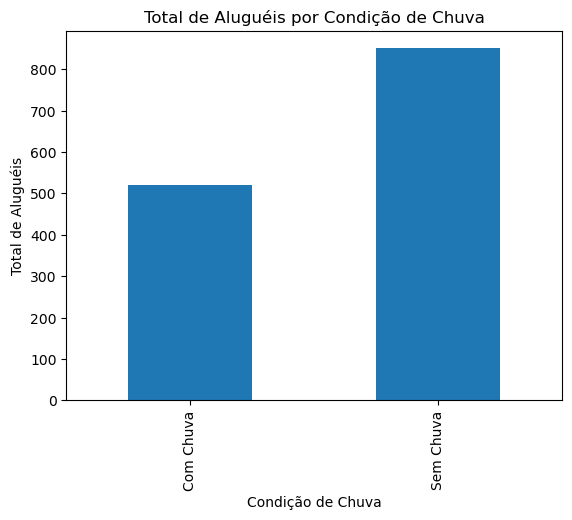

In [65]:
(
    df.groupby(
        np.where(df['Chuva'] == 0, 'Sem Chuva', 'Com Chuva')
    )['Aluguéis']
    .sum()
).plot(kind='bar')

plt.title('Total de Aluguéis por Condição de Chuva')
plt.xlabel('Condição de Chuva')
plt.ylabel('Total de Aluguéis')
plt.show()